In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from bioviper import selector 

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['font.sans-serif'] = 'Arial'

import pickle 

from studio_analysis_tools import *

/Users/sam/miniforge3/envs/sequences/lib/python3.10/site-packages/Bio/pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


In [2]:
DATA_PATH = "/Users/sam/Downloads/"
scores_path = f"{DATA_PATH}/SpecificityStudio_Jun2026.pkl"

with open(scores_path, 'rb') as infile:
    all_scores = pickle.load(infile)
    
# For EVE, we need to flip the sign of the scores so that higher is better to be able to compare with everything lese
for prot,dataset in all_scores.items():
    if 'EVE' in dataset:
        dataset.loc[:,'EVE'] = -dataset['EVE']

## Boxplots

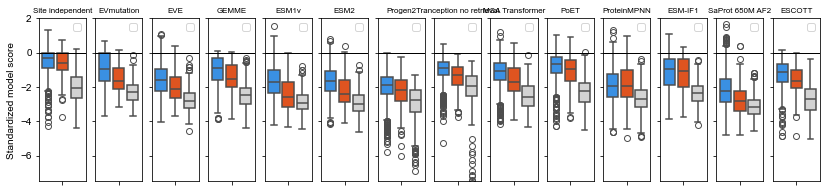

In [3]:
model_names = ['Site_independent', "EVmutation", "EVE", "GEMME", "ESM1v", "ESM2", "Progen2", "Tranception_no_retrieval", "MSA_Transformer", "PoET", "ProteinMPNN", "ESM-IF1", "SaProt_650M_AF2", "ESCOTT"]

data = all_scores['DLG4_HUMAN_Zarin_2024'].copy() # Feel free to swap out the dataset if you'd like to visualize another
data.loc['WT'] = data.loc['WT'].fillna(0)
fig, ax = StudioBoxplots(data, model_names, standardize_to_wt=True);
for axis in ax:
    axis.set_ylim(-7.5,2)
    
# The below plot is perfectly informative but needs some Illustrator Magic to look like it does in the paper (ughhhh)
# plt.savefig("model_comparison_boxplots.pdf", bbox_inches='tight')

## Scatterplots

I am going to remove these from the plot below but here is an attempt to label the scatterplots (this helped me adjuts for hte actual labeling in the paper fig):

In [4]:
model_nicknames = {
    "Site_independent": "PSSM",
    "EVmutation": "EVmutation",
    "EVE": "EVE",
    "GEMME": "GEMME",
    "ESM1v": "ESM1v",
    "ESM2": "ESM2",
    "Progen2": "Progen2",
    "Tranception_no_retrieval": "Tranception",
    "MSA_Transformer": "MSAT",
    "PoET": "PoET",
    "ProteinMPNN": "ProteinMPNN",
    "ESM-IF1": "ESM-IF1",
    "SaProt_650M_AF2": "SaProt",
    "ESCOTT": "ESCOTT"
}

def label_scatterplot(df, ax, force_text=(1.5, 1.5), force_points=(1.5, 1.5), expand=(1.5, 1.5)):
    texts = []
    for xi, yi, label in zip(df['AUC'], df['specificity_score'], df.index):
        texts.append(
            ax.text(
                xi, yi, model_nicknames.get(label, label),
                fontsize=9
            )
        )

    adjust_text(
        texts,
        x=df['AUC'], y=df['specificity_score'],                  # repel from these points
        ax=ax,
        force_text=force_text,      # repel labels from each other more
        force_points=force_points,    # repel labels from points more
        expand=expand,
        arrowprops=None
    )
    
    for text, xi, yi in zip(texts, df['AUC'], df['specificity_score']):
        x_text, y_text = text.get_position()
        ax.plot([xi, x_text], [yi, y_text], color="gray", lw=0.7)

Empty DataFrame
Columns: [specificity_category, ESCOTT]
Index: []
Error with model scores for ESCOTT
No model scores for MSA_Transformer


/Users/sam/Documents/GitHub/SpecificityStudio/Notebooks/studio_analysis_tools.py:141: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  wt_spearman = spearmanr(data_copy[model], data_copy[native_ligand])[0]


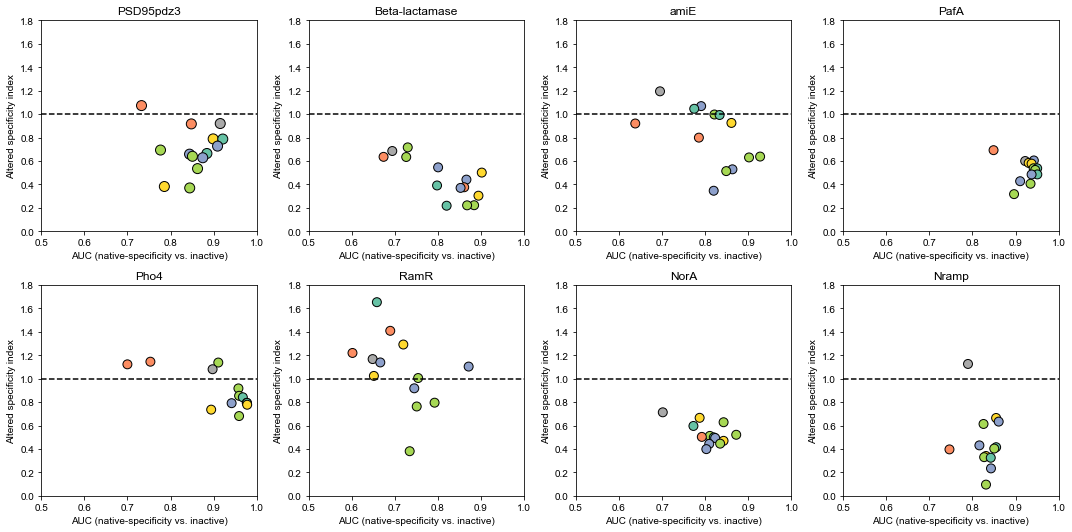

In [5]:
fig, ax = plt.subplots(2, 4, figsize=(15, 7.5))
ax = ax.flatten()

all_scores['BLAT_ECOLX_Stiffler_2015']['n_subs'] = [mutant.count(',') + 1 if mutant!='WT' else 0 for mutant in all_scores['BLAT_ECOLX_Stiffler_2015'].index]
pdz_scores_df, n_pdz_spec_alter = model_classification_plot(all_scores, 'DLG4_HUMAN_Zarin_2024', x="AUC", ax=ax[0], ms=100, title="PSD95pdz3")
#label_scatterplot(pdz_scores_df, ax[0])

amiE_scores_df, n_amiE_spec_alter = model_classification_plot(all_scores, 'AMIE_PSEAE_Wrenbeck_2017', x="AUC", ax=ax[2], title="amiE")
#label_scatterplot(amiE_scores_df, ax[2])

pafa_scores_df, n_pafa_spec_alter = model_classification_plot(all_scores, 'ALPH_ELIME_Markin_2021', x="AUC", ax=ax[3], title="PafA")
#label_scatterplot(pafa_scores_df, ax[3])

blat_scores_df, n_blat_spec_alter = model_classification_plot(all_scores, 'BLAT_ECOLX_Stiffler_2015', x="AUC", ax=ax[1], title="Beta-lactamase")
#label_scatterplot(blat_scores_df, ax[1])

ramR_scores_df, n_ramR_spec_alter = model_classification_plot(all_scores, 'HTHTR_SALTY_dOelsnitz_2025', x="AUC", ax=ax[5], title="RamR")
#label_scatterplot(ramR_scores_df, ax[5])

pho4_scores_df, n_pho4_spec_alter = model_classification_plot(all_scores, 'PHO4_YEAST_Aditham_2021', x="AUC", ax=ax[4], title="Pho4")
#label_scatterplot(pho4_scores_df, ax[4], force_points=(0.5,0.5))

norA_scores_df, n_norA_spec_alter = model_classification_plot(all_scores, 'NORA_STAAU_Miller_2025', x="AUC", ax=ax[6], title="NorA")
nramp_scores_df, n_nramp_spec_alter = model_classification_plot(all_scores, 'MNTH_DEIRA_Berry_2025', x="AUC", ax=ax[7], title="Nramp")
#label_scatterplot(norA_scores_df, ax[6])
#label_scatterplot(nramp_scores_df, ax[7])

for axis in ax:
    axis.set_ylim(0,1.8)
    axis.set_xlim(0.5,1.0)
    
plt.tight_layout()

plt.savefig("/Users/sam/Dropbox (Harvard University)/SpecificityStudio/Figures/Figure 2/model_classification_scatterplots_v3_use_only_for_PafA_surgery.pdf", bbox_inches='tight')

## Collecting everything

In [6]:
all_scores_dfs = {'pdz':pdz_scores_df, 'amiE':amiE_scores_df, 'pafa':pafa_scores_df, 'pho4':pho4_scores_df, 'ramR':ramR_scores_df, 'norA':norA_scores_df, 'nramp':nramp_scores_df, 'blat': blat_scores_df}
all_specificity_scores = pd.concat([pd.Series(df.specificity_score, name=protein) for protein,df in all_scores_dfs.items()], axis=1).drop("ProteinMPNN")
all_specificity_scores['mean'] = all_specificity_scores.mean(axis=1)

all_aucs = pd.concat([pd.Series(df.AUC, name=protein) for protein,df in all_scores_dfs.items()], axis=1)
all_aucs['mean'] = all_aucs.mean(axis=1)

Text(56.125, 0.5, 'AUC (native specificity vs inactive)')

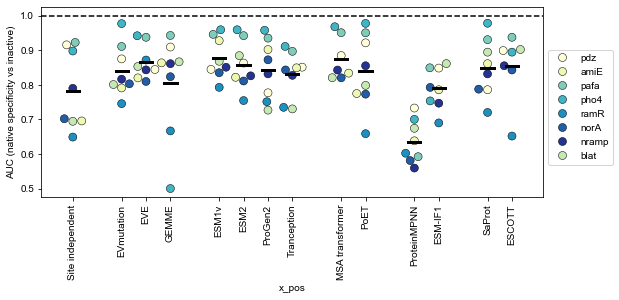

In [7]:
plt.figure(figsize=(9,3.5))
plt.axhline(1, c='k', ls='dashed')

data = all_aucs.sort_values('mean', ascending=False).T
data['protein'] = data.index.copy()

data_long = data.melt(id_vars='protein', value_vars = [i for i in model_names], var_name='model', value_name='AUC')
data_long = data_long.loc[data_long['protein']!='mean']

model_classification_filt = {m:cat for m,cat in model_classification.items() if m in model_names}
pos_dict = get_custom_coords(model_classification_filt, intra_gap=0.4, inter_gap=0.8)
data_long['x_pos'] = data_long['model'].map(pos_dict)

sns.swarmplot(data=data_long, hue='protein', y='AUC', x='x_pos', palette=map_cmap_to_proteins(protein_color_map, cm.YlGnBu), edgecolor='k', linewidth=0.5, s=8, native_scale=True)
plt.legend(loc='upper left', bbox_to_anchor=(1, 0.8))

mean_line_width = 0.2

data = all_aucs.loc[[i for i in model_names]].T
for model,x_pos in pos_dict.items():
    i = data.columns.get_loc(model)
    plt.plot([x_pos-mean_line_width/2, x_pos+mean_line_width/2], [data.iloc[-1,i], data.iloc[-1,i]], c='k', lw=3, zorder=10)

plt.xticks(list(pos_dict.values()), ['Site independent', 'EVmutation', 'EVE', 'GEMME', 'ESM1v', 'ESM2', 'ProGen2', 'Tranception', 'MSA transformer', 'PoET', 'ProteinMPNN', 'ESM-IF1', 'SaProt', 'ESCOTT'], rotation=90)
plt.ylabel("AUC (native specificity vs inactive)")

#plt.savefig('AUC_plot_model_order_grouped.pdf', bbox_inches='tight', dpi=300)

Text(56.0, 0.5, 'Altered specificity index')

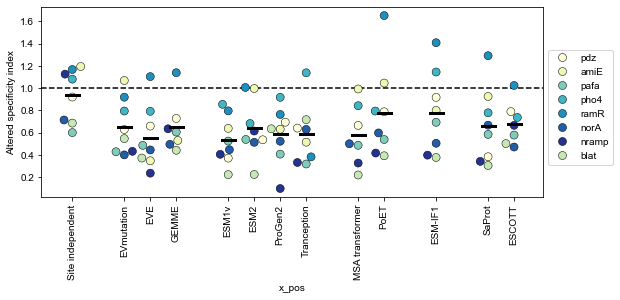

In [8]:
plt.figure(figsize=(9,3.5))
plt.axhline(1, c='k', ls='dashed')

data = all_specificity_scores.sort_values('mean', ascending=False).T
data['protein'] = data.index.copy()
data_long = data.melt(id_vars='protein', value_vars = [i for i in model_names if i!='ProteinMPNN'], var_name='model', value_name='ASI')
data_long = data_long.loc[data_long['protein']!='mean']

model_classification_filt = {m:cat for m,cat in model_classification.items() if m in model_names and m!='ProteinMPNN'}
pos_dict = get_custom_coords(model_classification_filt, intra_gap=0.4, inter_gap=0.8)
data_long['x_pos'] = data_long['model'].map(pos_dict)

sns.swarmplot(data=data_long, hue='protein', y='ASI', x='x_pos', palette=map_cmap_to_proteins(protein_color_map, cm.YlGnBu), edgecolor='k', linewidth=0.5, s=8, native_scale=True)
plt.legend(loc='upper left', bbox_to_anchor=(1, 0.8))

mean_line_width = 0.2

data = all_specificity_scores.loc[[i for i in model_names if i!='ProteinMPNN']].T
for model,x_pos in pos_dict.items():
    i = data.columns.get_loc(model)
    plt.plot([x_pos-mean_line_width/2, x_pos+mean_line_width/2], [data.iloc[-1,i], data.iloc[-1,i]], c='k', lw=3, zorder=10)

plt.xticks(list(pos_dict.values()), ['Site independent', 'EVmutation', 'EVE', 'GEMME', 'ESM1v', 'ESM2', 'ProGen2', 'Tranception', 'MSA transformer', 'PoET', 'ESM-IF1', 'SaProt', 'ESCOTT'], rotation=90)
plt.ylabel("Altered specificity index")

#plt.savefig('ASI_plot_model_order_grouped.pdf', bbox_inches='tight', dpi=300)